# Rain Prediction Backtesting Lab

Replay your Home Assistant rain-probability model against ground truth and tune it offline.

**Three data sources, one time grid:**
- **Local sensors** — your HA history CSV (temperature, humidity, and the live `rain_probability` your HA computed at the time).
- **open-meteo** — hourly `temperature_2m`, `relative_humidity_2m`, and `precipitation` (the **ground-truth label** for "did it actually rain").
- **Yandex** — archived `fact` snapshots (a third-party *observation* for cross-check; also carries pressure & wind if you want them later).

**What you can do here:**
1. Load & align everything.
2. Re-derive dew point / spread / derivative exactly like your HA helpers — but as tunable Python.
3. Run several candidate `rain_probability` models over the whole history.
4. Score them (precision / recall / F1 / lead-time) against real precipitation.
5. Sweep parameters and thresholds to see what *would* have happened.

> All model knobs live in a single `ModelParams` dataclass — change one number, re-run, see the effect on every past hour.


## 0. Setup

In [29]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import rainlib as rl
importlib.reload(rl)          # so edits to rainlib.py take effect without kernel restart
from rainlib import ModelParams, MODELS

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True


## 1. Point at your data

Edit the paths/globs below. You can keep appending new events over time — as long as the
files follow the same shapes, everything downstream just works.

- `HA_CSV` — Home Assistant history export (columns: `entity_id,state,last_changed`).
- `OM_SOURCES` — one or more open-meteo JSON responses. Each can be a **file path**, a **raw JSON string**, or an already-parsed dict. They get concatenated, so you can drop in a new day's pull anytime.
- `YANDEX_DIR` — a folder (searched recursively) of your archived Yandex JSON snapshots.

**Entity names:** map YOUR entity_ids to friendly names in `HA_ENTITIES`.


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# Paths (adjust these for your setup)
HA_CSV = 'data/ha.csv'           # Home Assistant sensor data
OM_SOURCES = ['data/openmeteo.json']  # Open-Meteo JSON file(s)
YANDEX_DIR = 'data/yandex/'      # Yandex Weather archive directory
METEOSTAT_JSON = 'data/meteostat.json'  # Meteostat data (optional)

# Entity mapping: HA entity_id -> friendly column name
HA_ENTITIES = {
    'sensor.datchik_klimata_temperatura': 'temp',
    'sensor.datchik_klimata_vlazhnost': 'rh',
    'sensor.rain_probability': 'ha_rain_prob',
}


In [30]:
# Override paths here if your data is somewhere else
# (Make sure to run this BEFORE running fetch scripts below)
# HA_CSV = 'path/to/your/ha.csv'
# OM_SOURCES = ['path/to/openmeteo.json']
# YANDEX_DIR = 'path/to/yandex/'


## Optional: Fetch Data

Uncomment and run these cells if you want to fetch fresh data directly from the notebook.

**Requirements:**
- Home Assistant token in `~/.homeassistant/ha_config.json` (format: `{"url": "http://homeassistant.local:8123", "token": "your_long_lived_access_token"}`)
- Internet access for Open-Meteo and Meteostat APIs
- Yandex archive available at configured URL

In [ ]:
# # Uncomment to fetch data:
# 
# # 1. Home Assistant
# !python fetch_ha_data.py --days 7 --output {HA_CSV}
# 
# # 2. Open-Meteo
# !python fetch_openmeteo.py --days 7 --output {OM_SOURCES[0]}
# 
# # 3. Meteostat
# !python fetch_meteostat.py --days 7 --output {METEOSTAT_JSON}
# 
# # 4. Yandex Weather archive
# !python fetch_yandex_archive.py --output {YANDEX_DIR}
# 
# print("✓ All data fetched")


## 2. Load & align onto one grid

In [31]:
# Load data from configured sources

# --- Home Assistant sensors ---
ha_long = rl.load_ha_csv(HA_CSV)
ha = rl.ha_wide(ha_long, HA_ENTITIES)

# --- Open-Meteo (concatenate all sources, dedupe on time) ---
om_frames = [rl.load_open_meteo(src) for src in OM_SOURCES]
om = pd.concat(om_frames).sort_index() if om_frames else pd.DataFrame()
if not om.empty:
    om = om[~om.index.duplicated(keep='first')]

# --- Yandex Weather archive ---
yx = rl.load_yandex_archive(YANDEX_DIR) if YANDEX_DIR else pd.DataFrame()

# --- Meteostat (optional) ---
try:
    ms = rl.load_meteostat(METEOSTAT_JSON) if METEOSTAT_JSON else pd.DataFrame()
except FileNotFoundError:
    print('Meteostat data not found, skipping')
    ms = pd.DataFrame()

print(f'Loaded: HA={len(ha)}, OM={len(om)}, YX={len(yx)}, MS={len(ms)}')


HA rows: 1111  ->  wide cols ['temp', 'rh', 'ha_rain_prob']
open-meteo hours: 120   cols ['om_temp', 'om_rh', 'om_precip', 'om_rain', 'om_showers']
yandex snapshots: 116   cols ['yx_condition', 'yx_temp', 'yx_humidity', 'yx_feels_like', 'yx_prec_prob', 'yx_prec_strength', 'yx_pressure_mm', 'yx_wind_speed', 'yx_is_rain']
unified grid: (860, 17) from 2026-06-30 21:00:00+00:00 to 2026-07-06 20:10:00+00:00


## 3. Re-derive local features (your HA helpers, as tunable Python)

These mirror your HA template sensors exactly, but are recomputed on the aligned grid so
temp & humidity always refer to the same instant (avoids the "spread from mismatched
timestamps" artifact you'd get computing on raw event rows).


In [32]:
grid['dew_point']    = rl.dew_point(grid['temp'], grid['rh'])
grid['spread']       = rl.dew_point_spread(grid['temp'], grid['rh'])
grid['abs_humidity'] = rl.absolute_humidity(grid['temp'], grid['rh'])
grid['humidex']      = rl.humidex(grid['temp'], grid['dew_point'])

# Derivative of the spread — this is the tunable analogue of your HA Derivative helper.
# Change the window to see how smoothing affects the trend signal (1h = twitchy, 3h = smooth).
DERIV_WINDOW = '3h'
grid['spread_deriv'] = rl.derivative(grid['spread'], window=DERIV_WINDOW)

grid[['temp','rh','dew_point','spread','spread_deriv','humidex']].describe().round(2)


,temp,rh,dew_point,spread,spread_deriv,humidex
count,605.00,601.00,589.00,589.00,588.00,589.00
mean,20.27,67.23,13.62,6.68,-0.10,23.50
std,4.52,12.44,2.62,3.36,1.10,5.66
min,13.70,35.00,9.25,1.96,-3.74,14.89
25%,16.40,60.00,11.46,4.39,-0.61,18.70
50%,19.40,69.00,13.28,5.88,-0.11,22.47
75%,22.70,76.00,15.70,8.37,0.33,27.99
max,30.90,88.00,19.28,17.24,4.29,35.03


## 4. Ground-truth label

`rain_truth = 1` when open-meteo precipitation for that hour ≥ `RAIN_THRESHOLD_MM`.
open-meteo precip is an hourly *sum for the preceding hour*, so a value at 14:00 describes
13:00–14:00. Raising the threshold (e.g. 0.2–0.3 mm) ignores trace drizzle and focuses on
rain you'd actually notice — worth trying both.


In [33]:
grid['rain_truth'] = rl.label_rain(grid, 'om_precip', threshold_mm=RAIN_THRESHOLD_MM)

# quick look at labelled rain hours
rain_hours = grid[grid['rain_truth']==1].resample('1h').last().dropna(subset=['rain_truth'])
print('Labelled rain hours:')
print(rain_hours[['om_precip']].dropna().round(2).to_string())


Labelled rain hours:
                           om_precip
time                                
2026-07-01 10:00:00+00:00        0.1
2026-07-01 17:00:00+00:00        0.3
2026-07-01 21:00:00+00:00        1.9
2026-07-01 22:00:00+00:00        1.2
2026-07-01 23:00:00+00:00        1.1
2026-07-02 00:00:00+00:00        0.6
2026-07-02 01:00:00+00:00        0.4
2026-07-02 09:00:00+00:00        0.1
2026-07-02 10:00:00+00:00        0.2
2026-07-02 12:00:00+00:00        0.2
2026-07-02 13:00:00+00:00        0.1
2026-07-02 14:00:00+00:00        0.9
2026-07-02 15:00:00+00:00        0.5
2026-07-02 21:00:00+00:00        0.4
2026-07-03 09:00:00+00:00        0.1
2026-07-03 10:00:00+00:00        0.1
2026-07-03 14:00:00+00:00        0.1
2026-07-03 15:00:00+00:00        0.6
2026-07-03 16:00:00+00:00        0.1
2026-07-03 17:00:00+00:00        0.3
2026-07-04 08:00:00+00:00        0.1
2026-07-04 09:00:00+00:00        0.2
2026-07-04 11:00:00+00:00        1.5
2026-07-04 12:00:00+00:00        0.9
2026-07-04 13:00:

## 5. Run the candidate models over all history

`MODELS` registry (in `rainlib.py`):
- **original** — your first formula (`proximity*0.7 + trend*0.7`, no hysteresis). Reference baseline.
- **tuned** — recalibrated proximity + capped trend downside + hysteresis (slow decay).
- **trend_dominant** — trend is the primary driver, spread only a dryness ceiling.

Also carried along: **`ha_rain_prob`** = what your HA actually output live at the time, so you can
see whether the offline reimplementations match / improve on reality.


In [34]:
params = ModelParams(
    proximity_divisor = 7.0,
    trend_gain        = 20.0,
    trend_floor       = -15.0,
    trend_ceiling     = 30.0,
    proximity_weight  = 0.8,
    trend_weight      = 0.5,
    dry_spread_cutoff = 10.0,
    dry_ceiling       = 40.0,
    hysteresis_decay  = 0.30,
)

for name, fn in MODELS.items():
    grid[f'model_{name}'] = fn(grid['spread'], grid['spread_deriv'], params)

model_cols = [f'model_{n}' for n in MODELS] + ['ha_rain_prob']
grid[model_cols].describe().round(1)


,model_original,model_tuned,model_trend_dominant,ha_rain_prob
count,588.0,749.0,749.0,533.0
mean,24.1,26.4,11.3,27.5
std,20.3,20.0,18.9,20.0
min,0.0,0.0,0.0,0.0
25%,5.8,8.0,0.0,12.0
50%,20.0,22.0,2.0,27.0
75%,41.0,47.0,16.0,41.0
max,76.0,68.0,100.0,78.0


## 6. Score every model (precision / recall / F1 + lead time)

In [35]:
DECISION_THRESHOLD = 50.0   # pred >= this is treated as "rain predicted"

rows = []
for col in model_cols:
    c = rl.confusion_at_threshold(grid[col], grid['rain_truth'], DECISION_THRESHOLD)
    lt = rl.lead_time(grid[col], grid['rain_truth'], DECISION_THRESHOLD)
    rows.append({
        'model': col,
        'precision': round(c['precision'],2) if c['precision']==c['precision'] else None,
        'recall':    round(c['recall'],2)    if c['recall']==c['recall'] else None,
        'f1':        round(c['f1'],2)         if c['f1']==c['f1'] else None,
        'tp': c['tp'], 'fp': c['fp'], 'fn': c['fn'], 'tn': c['tn'],
        'lead_time': str(lt) if lt is not None else 'never',
    })
score = pd.DataFrame(rows).set_index('model')
score


,precision,recall,f1,tp,fp,fn,tn,lead_time
model,,,,,,,,
model_original,0.68,0.23,0.35,60,28,198,302,never
model_tuned,0.67,0.23,0.34,62,30,208,449,never
model_trend_dominant,0.61,0.10,0.17,27,17,243,462,never
ha_rain_prob,0.57,0.15,0.24,39,30,216,248,never


**Reading this table**
- **precision** — of the hours it cried rain, what fraction really rained (low = false alarms).
- **recall** — of the hours it really rained, what fraction it caught (low = misses).
- **lead_time** — how far *before* the first rain hour the model first crossed the threshold (early warning). `never` = it didn't fire before onset.

There is always a precision/recall trade-off; the threshold sweep below makes it explicit.


## 7. Threshold sweep — pick your operating point

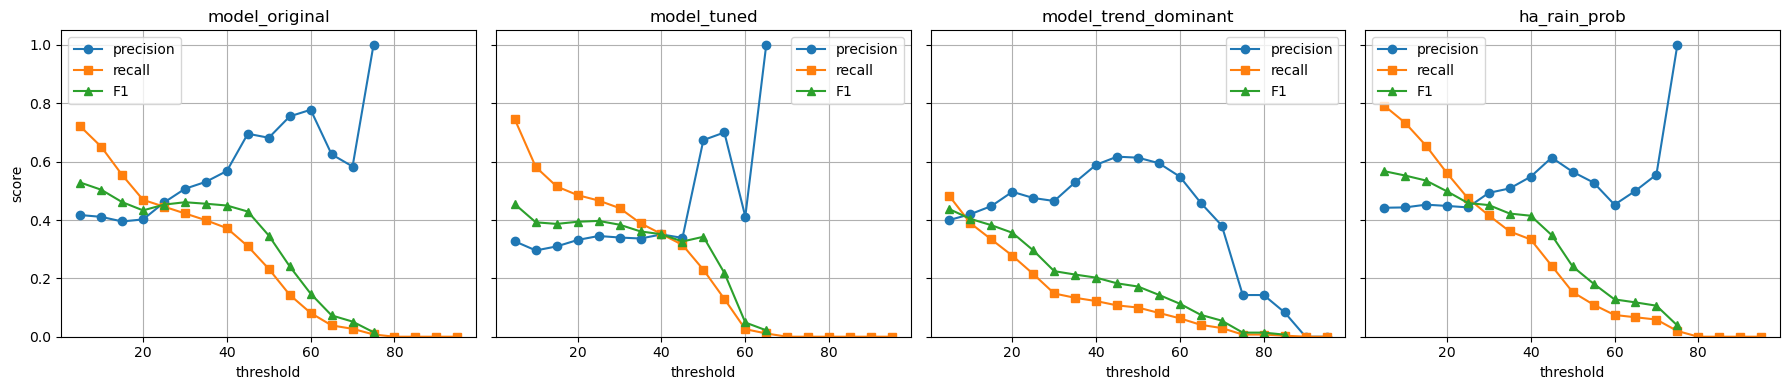

In [36]:
fig, axes = plt.subplots(1, len(model_cols), figsize=(4.5*len(model_cols), 4), sharey=True)
if len(model_cols)==1: axes=[axes]
for ax, col in zip(axes, model_cols):
    sw = rl.sweep_threshold(grid[col], grid['rain_truth'], thresholds=range(5,100,5))
    ax.plot(sw.index, sw['precision'], 'o-', label='precision')
    ax.plot(sw.index, sw['recall'],    's-', label='recall')
    ax.plot(sw.index, sw['f1'],        '^-', label='F1')
    ax.set_title(col); ax.set_xlabel('threshold'); ax.legend(); ax.set_ylim(0,1.05)
axes[0].set_ylabel('score')
plt.tight_layout(); plt.show()


## 8. The money plot — timeline overlay

Every model's probability over time, with **actual rain hours shaded**. This is where you *see*
the failure modes we found: the post-peak crash during ongoing rain, and the dry-night false
positive where spread closed as tightly as a real rain night.


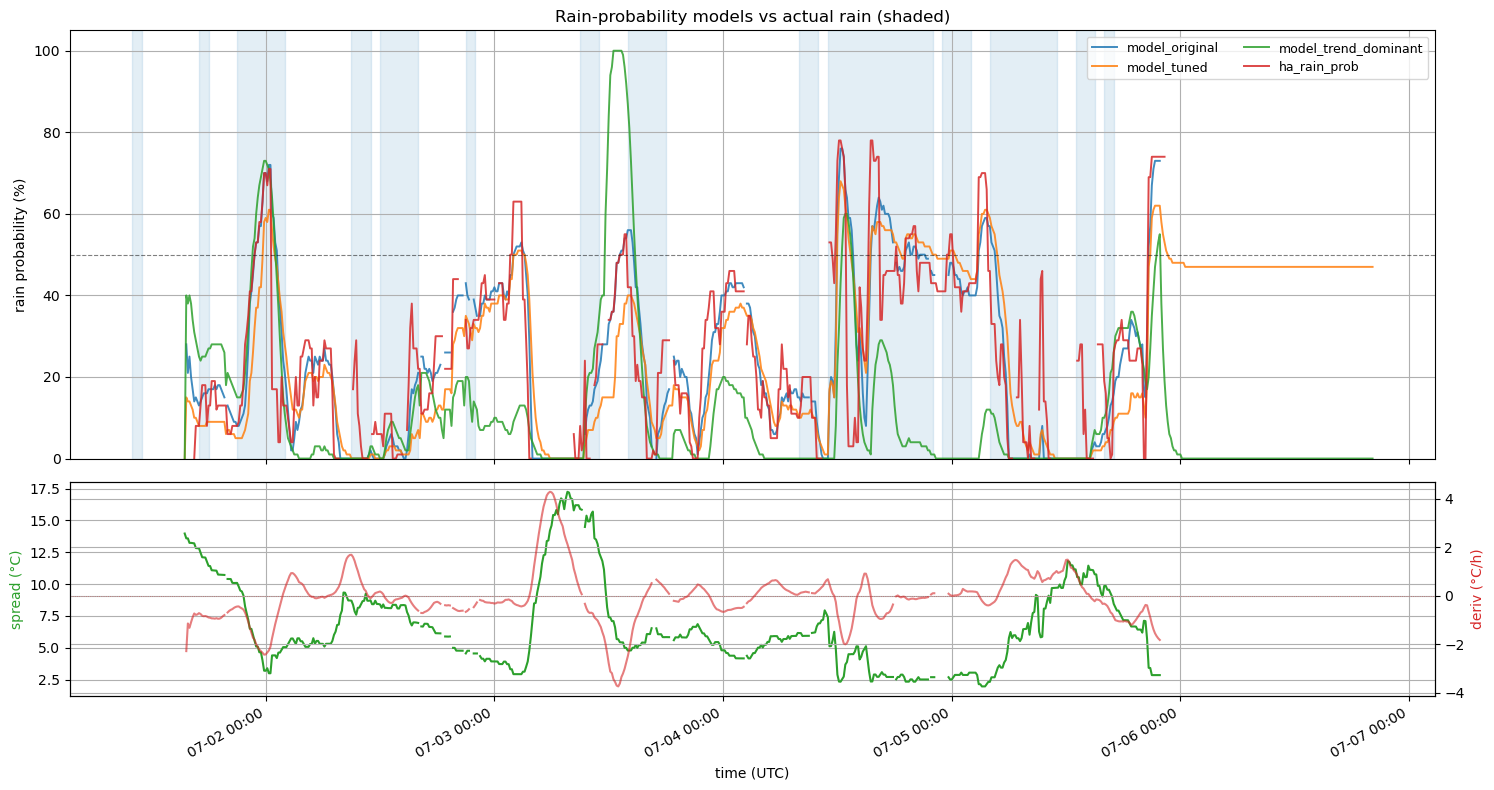

In [37]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# --- top: model probabilities + rain shading ---
for col in model_cols:
    ax1.plot(grid.index, grid[col], label=col, alpha=0.85, linewidth=1.4)

# shade actual rain hours
truth = grid['rain_truth'].fillna(0)
in_rain = False
for t, v in truth.items():
    if v==1 and not in_rain:
        start=t; in_rain=True
    elif v==0 and in_rain:
        ax1.axvspan(start, t, color='tab:blue', alpha=0.12); in_rain=False
if in_rain: ax1.axvspan(start, truth.index[-1], color='tab:blue', alpha=0.12)

ax1.axhline(DECISION_THRESHOLD, color='k', ls='--', lw=0.8, alpha=0.5)
ax1.set_ylabel('rain probability (%)'); ax1.set_ylim(0,105)
ax1.legend(loc='upper right', ncol=2, fontsize=9)
ax1.set_title('Rain-probability models vs actual rain (shaded)')

# --- bottom: the underlying drivers ---
ax2.plot(grid.index, grid['spread'], color='tab:green', label='dew-point spread (°C)')
ax2b = ax2.twinx()
ax2b.plot(grid.index, grid['spread_deriv'], color='tab:red', alpha=0.6, label='spread deriv (°C/h)')
ax2b.axhline(0, color='tab:red', ls=':', lw=0.6, alpha=0.5)
ax2.set_ylabel('spread (°C)', color='tab:green')
ax2b.set_ylabel('deriv (°C/h)', color='tab:red')
ax2.set_xlabel('time (UTC)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.show()


## 9. Cross-check the three sources against each other

Sanity: do your local sensor, open-meteo, and Yandex even agree on the basic state of the air?
Big persistent gaps here point at sensor placement / calibration rather than model error.


In [38]:
cmp = grid.resample('1h').last()
cols = [c for c in ['temp','om_temp','yx_temp','rh','om_rh','yx_humidity',
                    'ha_rain_prob','om_precip','yx_prec_prob','yx_condition']
        if c in cmp.columns]
cmp[cols].dropna(how='all').round(1)


,temp,om_temp,yx_temp,rh,om_rh,yx_humidity,ha_rain_prob,om_precip,yx_prec_prob,yx_condition
time,,,,,,,,,,
2026-06-30 21:00:00+00:00,NaN,24.2,NaN,NaN,67.0,NaN,NaN,0.0,NaN,None
2026-06-30 22:00:00+00:00,NaN,23.2,NaN,NaN,69.0,NaN,NaN,0.0,NaN,None
2026-06-30 23:00:00+00:00,NaN,22.5,NaN,NaN,70.0,NaN,NaN,0.0,NaN,None
2026-07-01 00:00:00+00:00,NaN,21.2,NaN,NaN,73.0,NaN,NaN,0.0,NaN,None
2026-07-01 01:00:00+00:00,NaN,20.4,NaN,NaN,72.0,NaN,NaN,0.0,NaN,None
...,...,...,...,...,...,...,...,...,...,...
2026-07-06 16:00:00+00:00,NaN,NaN,17.0,NaN,NaN,66.0,NaN,NaN,0.0,cloudy
2026-07-06 17:00:00+00:00,NaN,NaN,17.0,NaN,NaN,60.0,NaN,NaN,0.0,cloudy
2026-07-06 18:00:00+00:00,NaN,NaN,16.0,NaN,NaN,59.0,NaN,NaN,0.0,overcast


## 10. Parameter tuning loop

Grid-search (or hand-tweak) `ModelParams` and watch F1 respond. Because everything is offline
and vectorised, you can try dozens of combinations in seconds. Add pressure later as a new
feature/column and a new model in `rainlib.py` — the harness doesn't change.


In [39]:
import itertools

grid_search = {
    'proximity_divisor': [5, 6, 7, 8],
    'hysteresis_decay':  [0.2, 0.3, 0.5],
    'trend_gain':        [15, 20, 30],
}

results = []
keys = list(grid_search)
for combo in itertools.product(*grid_search.values()):
    kw = dict(zip(keys, combo))
    p = ModelParams(**kw)
    pred = rl.model_tuned(grid['spread'], grid['spread_deriv'], p)
    c = rl.confusion_at_threshold(pred, grid['rain_truth'], DECISION_THRESHOLD)
    results.append({**kw,
                    'precision': c['precision'], 'recall': c['recall'], 'f1': c['f1']})

res = pd.DataFrame(results).sort_values('f1', ascending=False, na_position='last')
res.head(15).round(3)


,proximity_divisor,hysteresis_decay,trend_gain,precision,recall,f1
19,7,0.2,20,0.670,0.270,0.385
20,7,0.2,30,0.658,0.270,0.383
18,7,0.2,15,0.703,0.263,0.383
23,7,0.3,30,0.688,0.244,0.361
21,7,0.3,15,0.709,0.226,0.343
22,7,0.3,20,0.674,0.230,0.343
28,8,0.2,20,0.349,0.330,0.339
29,8,0.2,30,0.345,0.326,0.335
27,8,0.2,15,0.345,0.326,0.335
26,7,0.5,30,0.699,0.215,0.329


### Notes & next steps

- **Trace-rain sensitivity.** Try `RAIN_THRESHOLD_MM = 0.2` or `0.3` and re-run from §4. Many of the
  "misses" are sub-0.2 mm hours (barely-there drizzle) that no surface-humidity model can be
  expected to nail.
- **Pressure is the missing feature.** The backtests show dew-point spread alone can't separate a
  real rain night from an ordinary calm-cooling night. When you add a BME280, log its pressure into
  HA, export it in the same CSV, add a `pressure` column here, and write a `model_pressure_aware`
  in `rainlib.py` that fires on a pressure *drop rate*. The scoring/plot cells work unchanged.
- **More events = trustworthy tuning.** One or two events over-fit easily. Keep appending days to
  `OM_SOURCES`, the Yandex folder, and your HA CSV; the harness scales to as much history as you feed it.
- **Ground truth choice.** open-meteo precip is reanalysis, not your exact roof. If you ever add a
  physical rain sensor / tipping bucket, swap it in as the label in §4 for the most honest local score.
